<a href="https://colab.research.google.com/github/jiannyuhs-hue/ADALL_github/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
# Example: Replace this with the raw URL of your GitHub file
github_raw_url = 'https://raw.githubusercontent.com/jiannyuhs-hue/ADALL_github/refs/heads/main/laptop_prices_2024_sgd_TL.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Successfully loaded data from GitHub!")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")

Successfully loaded data from GitHub!


,Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,SSD,256,False,1.56,16.0,3.27,2413.36,5,144.80
1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,SSD,1024,True,1.45,14.0,5.03,1773.75,5,124.16
2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,SSD,2048,False,1.34,14.0,4.41,1634.07,5,98.04
3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,SSD,4096,True,1.18,13.3,2.16,2362.59,5,118.13
4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,SSD,1024,True,1.31,14.0,6.93,2218.55,5,155.30


In [8]:
!pip install openai pandas numpy matplotlib seaborn python-dotenv

In [10]:
from google.colab import userdata
from openai import OpenAI

# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    api_key=api_key,
)

In [11]:
import openai
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from datetime import datetime

In [14]:
print(f"Data Shape: {df.shape}")
print(f"Data Types: \n{df.dtypes}")
print

Data Shape: (1000, 14)
Data Types: 
Brand                object
Model                object
CPU                  object
GPU                  object
RAM_GB                int64
Storage_Type         object
Storage_GB            int64
Touchscreen            bool
Weight_kg           float64
Screen_Size_inch    float64
Discount_percent    float64
Price_SGD           float64
Brand_Discount        int64
Member_Discount     float64
dtype: object


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [17]:
print("\nData Structure")
print(df.info())


Data Structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Model             1000 non-null   object 
 2   CPU               1000 non-null   object 
 3   GPU               1000 non-null   object 
 4   RAM_GB            1000 non-null   int64  
 5   Storage_Type      1000 non-null   object 
 6   Storage_GB        1000 non-null   int64  
 7   Touchscreen       1000 non-null   bool   
 8   Weight_kg         1000 non-null   float64
 9   Screen_Size_inch  1000 non-null   float64
 10  Discount_percent  1000 non-null   float64
 11  Price_SGD         1000 non-null   float64
 12  Brand_Discount    1000 non-null   int64  
 13  Member_Discount   1000 non-null   float64
dtypes: bool(1), float64(5), int64(3), object(5)
memory usage: 102.7+ KB
None


In [22]:
print("\nSummary Statistics")
df.describe(include='all')


Summary Statistics


,Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
count,1000,1000,1000,1000,1000.000000,1000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000
unique,6,30,10,9,NaN,1,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
top,Asus,Predator Helios 300,Intel i5-14600H,NVIDIA RTX 4070,NaN,SSD,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
freq,177,48,114,268,NaN,1000,NaN,505,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,53.128000,NaN,1505.024000,NaN,2.036560,15.645700,7.538230,2277.796410,6.7680,135.810660
std,NaN,NaN,NaN,NaN,44.413288,NaN,1380.203919,NaN,0.746477,1.759846,4.334012,616.496246,2.6346,41.344593
min,NaN,NaN,NaN,NaN,8.000000,NaN,256.000000,NaN,1.000000,13.300000,0.000000,995.770000,3.0000,50.740000
25%,NaN,NaN,NaN,NaN,16.000000,NaN,512.000000,NaN,1.340000,14.000000,3.815000,1776.212500,5.0000,103.435000
50%,NaN,NaN,NaN,NaN,32.000000,NaN,1024.000000,NaN,1.970000,15.600000,7.480000,2257.765000,7.0000,131.095000
75%,NaN,NaN,NaN,NaN,64.000000,NaN,2048.000000,NaN,2.680000,17.300000,11.225000,2711.680000,10.0000,163.052500


In [23]:
# Count missing values and percent
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

# Print summary table
print("\nMissing values summary (sorted by count):\n")
print(missing_summary.to_string())

# Highlight "significant" missingness: define threshold (e.g., >5% missing)
threshold_pct = 5.0
significant_missing = missing_summary[missing_summary["missing_percent"] > threshold_pct]
if not significant_missing.empty:
    print(f"\nColumns with >{threshold_pct}% missing values:\n")
    print(significant_missing.to_string())
else:
    print(f"\nNo columns with >{threshold_pct}% missing values.\n")


Missing values summary (sorted by count):

                  missing_count  missing_percent
Brand                         0              0.0
Model                         0              0.0
CPU                           0              0.0
GPU                           0              0.0
RAM_GB                        0              0.0
Storage_Type                  0              0.0
Storage_GB                    0              0.0
Touchscreen                   0              0.0
Weight_kg                     0              0.0
Screen_Size_inch              0              0.0
Discount_percent              0              0.0
Price_SGD                     0              0.0
Brand_Discount                0              0.0
Member_Discount               0              0.0

No columns with >5.0% missing values.



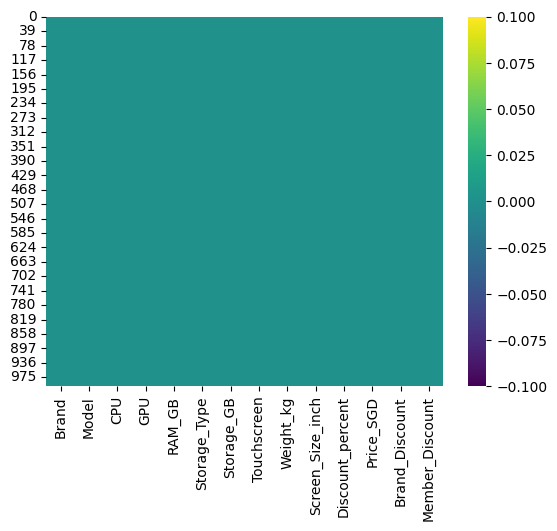

In [24]:
#plot a heat map for missing value
sns.heatmap(df.isnull(), cmap='viridis')
plt.show()
#

In [25]:
# count of rows that are duplicates (including all copies)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows (including all copies): {duplicate_count}")

Number of duplicate rows (including all copies): 0


In [27]:
# count of rows that are duplicates (including all copies)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows (including all copies): {duplicate_count}")
# If duplicates exist, show some examples
if duplicate_count > 0:
    print("\nExamples of duplicate rows:")
    print(df[df.duplicated()].head())
else:
    print("\nNo duplicate rows found.")

Number of duplicate rows (including all copies): 0

No duplicate rows found.
